# C-MAPSS Modeling — `modeling_dev_trial`
## Best-of-everything single-config run with research-backed improvements

This notebook combines:

1. **Best v6 hyperparameters** — single seed 42, config that performed best
2. **lstm2 design choices** — SmoothL1Loss (Huber), MinMaxScaler [0,1], window W=50
3. **v4-style simpler DANN** — unidirectional LSTM h=64, plain training, no over-engineering
4. **Research-backed modules**:
   - Regression-based op-condition normalization (Hong et al. 2026, arxiv 2601.10269)
   - Random Forest feature importance pre-screen (Bi-cLSTM, Sensors 2026)
   - Lower learning rate in adversarial phase (Costa et al. 2019)
   - MMD as auxiliary loss alongside adversarial DANN (Long et al. 2015)

### Goal

- SimpleLSTM on FD001: target RMSE 14-15 (matching lstm2 / Costa 2019)
- DANN+MMD on FD001->FD002: target RMSE under 30 (beating v6/v7 at 54-55)

### Why simpler often wins

v4 unidirectional LSTM DANN got FD002 RMSE **51.70**, beating v6 stage-aware two-phase BiLSTM at 54.88. Smaller encoders generalize better across domains because they cannot memorize source-specific features.

### W=50 evaluation

Window size 50 means 7 of FD001's 100 test engines have fewer than 50 cycles. We report **both**: full 100 engines (front-padded) and the subset that fit (lstm2's implicit choice). This is the honest version of what lstm2 silently did.

### Wall time on M4-MPS: ~25 minutes


## §1 — Setup

In [1]:
import os, time, random, math, json, itertools, copy
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display, clear_output

if torch.cuda.is_available():             Device = 'cuda'
elif torch.backends.mps.is_available():   Device = 'mps'
else:                                     Device = 'cpu'
print(f'Device : {Device}')
print(f'PyTorch: {torch.__version__}')

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('CMAPSSData')
CKPT_DIR = Path('checkpoints_dev'); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path('figures_dev');     FIG_DIR.mkdir(exist_ok=True)
assert DATA_DIR.exists(), 'Place CMAPSSData/ next to this notebook.'

SEED = 42

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print('Seed set:', SEED)


Device : mps
PyTorch: 2.11.0
Seed set: 42


## §2 — Data loading

Load FD001 and FD002. FD002 serves as unlabeled target domain for DANN and as the supervised upper bound.


In [2]:
COLS = (['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3']
        + [f's_{i}' for i in range(1, 22)])
SENSORS_ALL = [c for c in COLS if c.startswith('s_')]
SETTINGS    = ['setting_1', 'setting_2', 'setting_3']

def load_subset(subset):
    train = pd.read_csv(DATA_DIR / f'train_{subset}.txt', sep=r'\s+',
                        header=None, names=COLS, engine='python')
    test  = pd.read_csv(DATA_DIR / f'test_{subset}.txt',  sep=r'\s+',
                        header=None, names=COLS, engine='python')
    rul   = pd.read_csv(DATA_DIR / f'RUL_{subset}.txt',   sep=r'\s+',
                        header=None, names=['RUL'], engine='python')['RUL'].values
    return train, test, rul

def add_rul(df):
    df = df.copy()
    df['RUL'] = df.groupby('unit')['cycle'].transform('max') - df['cycle']
    return df

fd1_train_raw, fd1_test_raw, fd1_true_rul = load_subset('FD001')
fd2_train_raw, fd2_test_raw, fd2_true_rul = load_subset('FD002')
fd1_train_raw = add_rul(fd1_train_raw)
fd2_train_raw = add_rul(fd2_train_raw)

print(f'FD001 train: {fd1_train_raw["unit"].nunique()} engines, {len(fd1_train_raw):,} rows')
print(f'FD001 test : {fd1_test_raw["unit"].nunique()} engines')
print(f'FD002 train: {fd2_train_raw["unit"].nunique()} engines, {len(fd2_train_raw):,} rows')
print(f'FD002 test : {fd2_test_raw["unit"].nunique()} engines')


FD001 train: 100 engines, 20,631 rows
FD001 test : 100 engines
FD002 train: 260 engines, 53,759 rows
FD002 test : 259 engines


## §3 — Regression-based operating-condition normalization

**Research basis:** Hong et al. 2026 (arxiv 2601.10269). Fit a linear regression predicting each sensor's expected value from operating settings, then z-score the *residual*. This removes multi-regime artifacts while preserving degradation signal.

**Why this fixes v6/v7:** KMeans cluster normalization broke in v7 (overflow warnings, lower bound at 59 RMSE instead of expected ~22). The regression approach needs no clustering and applies identically to both domains -- correct for unsupervised DA.


In [3]:
def fit_regime_regression(train_df, sensors, settings):
    models = {}
    X = train_df[settings].values
    for s in sensors:
        m = LinearRegression()
        m.fit(X, train_df[s].values)
        models[s] = m
    return models

def apply_regime_regression(df, models, sensors, settings):
    df = df.copy()
    X = df[settings].values
    for s in sensors:
        df[s] = df[s].values - models[s].predict(X)
    return df

# Fit on combined FD001+FD002 (no labels used -- only settings and raw sensors)
combined = pd.concat(
    [fd1_train_raw[SETTINGS + SENSORS_ALL], fd2_train_raw[SETTINGS + SENSORS_ALL]],
    axis=0, ignore_index=True,
)
regime_models = fit_regime_regression(combined, SENSORS_ALL, SETTINGS)

fd1_train = apply_regime_regression(fd1_train_raw, regime_models, SENSORS_ALL, SETTINGS)
fd1_test  = apply_regime_regression(fd1_test_raw,  regime_models, SENSORS_ALL, SETTINGS)
fd2_train = apply_regime_regression(fd2_train_raw, regime_models, SENSORS_ALL, SETTINGS)
fd2_test  = apply_regime_regression(fd2_test_raw,  regime_models, SENSORS_ALL, SETTINGS)

# Z-score residuals using FD001 train stats only
res_means = fd1_train[SENSORS_ALL].mean()
res_stds  = fd1_train[SENSORS_ALL].std().replace(0, 1.0)
for df in [fd1_train, fd1_test, fd2_train, fd2_test]:
    df[SENSORS_ALL] = (df[SENSORS_ALL] - res_means) / res_stds

print('After regime-regression normalization:')
print(f'  FD001 train sensor |mean| max: {fd1_train[SENSORS_ALL].mean().abs().max():.4f}  (should be ~0)')
print(f'  FD001 train sensor std mean  : {fd1_train[SENSORS_ALL].std().mean():.4f}  (should be ~1)')
print(f'  FD002 train sensor |mean| max: {fd2_train[SENSORS_ALL].mean().abs().max():.4f}')


After regime-regression normalization:
  FD001 train sensor |mean| max: 0.0000  (should be ~0)
  FD001 train sensor std mean  : 0.9524  (should be ~1)
  FD002 train sensor |mean| max: 614.2168


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value

## §4 — Random Forest feature importance pre-screen

**Research basis:** Bi-cLSTM (Sensors 2026). RF regressor on RUL; drop sensors with importance below 1e-3. Fit on FD001 train only.


In [4]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(fd1_train[SENSORS_ALL].values, fd1_train_raw['RUL'].values)
importances = pd.Series(rf.feature_importances_, index=SENSORS_ALL).sort_values(ascending=False)

print('RF sensor importance on FD001:')
for s, imp in importances.items():
    marker = 'DROP' if imp < 1e-3 else 'keep'
    print(f'  [{marker}] {s:5s}: {imp:.5f}')

RF_THRESHOLD = 1e-3
USE_SENSORS  = [s for s, imp in importances.items() if imp >= RF_THRESHOLD]
DROP_SENSORS = [s for s, imp in importances.items() if imp < RF_THRESHOLD]
print(f'\n=> Keeping {len(USE_SENSORS)}, dropping {len(DROP_SENSORS)}: {DROP_SENSORS}')


RF sensor importance on FD001:
  [keep] s_11 : 0.60276
  [keep] s_9  : 0.14071
  [keep] s_4  : 0.07910
  [keep] s_12 : 0.03309
  [keep] s_7  : 0.02205
  [keep] s_14 : 0.01935
  [keep] s_13 : 0.01486
  [keep] s_15 : 0.01474
  [keep] s_21 : 0.01196
  [keep] s_20 : 0.00967
  [keep] s_8  : 0.00950
  [keep] s_2  : 0.00928
  [keep] s_17 : 0.00917
  [keep] s_3  : 0.00865
  [keep] s_5  : 0.00316
  [keep] s_6  : 0.00310
  [keep] s_18 : 0.00230
  [keep] s_10 : 0.00225
  [keep] s_1  : 0.00215
  [keep] s_16 : 0.00214
  [DROP] s_19 : 0.00000

=> Keeping 20, dropping 1: ['s_19']


## §5 — MinMax scaling, W=50, datasets

MinMaxScaler [0,1] on normalized residuals matches lstm2. W=50 gives more context. We build both evaluation flavors: front-padded (all engines) and dropped (only >=50 cycles).


In [5]:
W        = 50
RUL_CLIP = 125

scaler = MinMaxScaler()
scaler.fit(fd1_train[USE_SENSORS])
for df in [fd1_train, fd1_test, fd2_train, fd2_test]:
    df[USE_SENSORS] = scaler.transform(df[USE_SENSORS])

print(f'After MinMax: range [{fd1_train[USE_SENSORS].min().min():.4f}, '
      f'{fd1_train[USE_SENSORS].max().max():.4f}]')


class CMAPSSWindowDataset(Dataset):
    def __init__(self, df, sensors, window, rul_clip):
        self.X, self.y = [], []
        for _, eng in df.groupby('unit'):
            arr  = eng[sensors].values.astype(np.float32)
            ruls = np.minimum(eng['RUL'].values.astype(np.float32), rul_clip)
            L = len(arr)
            if L < window: continue
            for end in range(window, L + 1):
                self.X.append(arr[end - window: end])
                self.y.append(ruls[end - 1])
        self.X = np.stack(self.X)
        self.y = np.array(self.y, dtype=np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])


def build_test_padded(df, sensors, window):
    Xs = []
    for _, eng in df.groupby('unit'):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], axis=0))
    return np.stack(Xs)


def build_test_dropped(df, sensors, window):
    Xs, kept = [], []
    for i, (_, eng) in enumerate(df.groupby('unit')):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
            kept.append(i)
    return np.stack(Xs), np.array(kept)


rng       = np.random.default_rng(SEED)
src_units = fd1_train['unit'].unique()
val_units = rng.choice(src_units, size=int(0.2 * len(src_units)), replace=False)
val_mask  = fd1_train['unit'].isin(val_units)

fd1_train_set = CMAPSSWindowDataset(fd1_train[~val_mask], USE_SENSORS, W, RUL_CLIP)
fd1_val_set   = CMAPSSWindowDataset(fd1_train[ val_mask], USE_SENSORS, W, RUL_CLIP)
fd2_train_set = CMAPSSWindowDataset(fd2_train, USE_SENSORS, W, RUL_CLIP)

rng2         = np.random.default_rng(SEED)
fd2_units    = fd2_train['unit'].unique()
fd2_val_u    = rng2.choice(fd2_units, size=int(0.2 * len(fd2_units)), replace=False)
fd2_val_mask = fd2_train['unit'].isin(fd2_val_u)
fd2_ub_train = CMAPSSWindowDataset(fd2_train[~fd2_val_mask], USE_SENSORS, W, RUL_CLIP)
fd2_ub_val   = CMAPSSWindowDataset(fd2_train[ fd2_val_mask], USE_SENSORS, W, RUL_CLIP)

X_test_fd1_pad = build_test_padded(fd1_test, USE_SENSORS, W)
X_test_fd1_drp, idx_fd1 = build_test_dropped(fd1_test, USE_SENSORS, W)
y_test_fd1_pad = fd1_true_rul.astype(np.float32)
y_test_fd1_drp = fd1_true_rul[idx_fd1].astype(np.float32)

X_test_fd2_pad = build_test_padded(fd2_test, USE_SENSORS, W)
X_test_fd2_drp, idx_fd2 = build_test_dropped(fd2_test, USE_SENSORS, W)
y_test_fd2_pad = fd2_true_rul.astype(np.float32)
y_test_fd2_drp = fd2_true_rul[idx_fd2].astype(np.float32)

print(f'FD001 train: {len(fd1_train_set):,} | val: {len(fd1_val_set):,}')
print(f'FD002 tgt  : {len(fd2_train_set):,}')
print(f'FD001 test padded={X_test_fd1_pad.shape[0]}  dropped={X_test_fd1_drp.shape[0]} ({100-X_test_fd1_drp.shape[0]} short)')
print(f'FD002 test padded={X_test_fd2_pad.shape[0]}  dropped={X_test_fd2_drp.shape[0]}')


After MinMax: range [0.0000, 1.0000]
FD001 train: 12,470 | val: 3,261
FD002 tgt  : 41,019
FD001 test padded=100  dropped=93 (7 short)
FD002 test padded=259  dropped=235


## §6 — Evaluation utilities

In [6]:
def asymmetric_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.where(d < 0, np.exp(-d/13.0)-1, np.exp(d/10.0)-1).sum())


def score_predictions(y_true, y_pred_raw, label=''):
    y_pred = np.clip(y_pred_raw, 0, None)
    rmse  = math.sqrt(np.mean((y_pred - y_true)**2))
    score = asymmetric_score(y_true, y_pred)
    mae   = float(np.mean(np.abs(y_pred - y_true)))
    bias  = float((y_pred - y_true).mean())
    if label: print(f'[{label}]')
    print(f'  RMSE={rmse:.3f}  Score={score:.0f}  MAE={mae:.3f}  Bias={bias:+.3f}')
    return dict(rmse=rmse, score=score, mae=mae, bias=bias)


@torch.no_grad()
def run_inference(model, X, device, mode='lstm', batch_size=256):
    model.eval(); preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        preds.append((model(xb) if mode=='lstm' else model.predict_rul(xb)).cpu().numpy())
    return np.concatenate(preds)


@torch.no_grad()
def evaluate_loader(model, loader, device, mode='lstm'):
    model.eval(); sq_err, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb) if mode=='lstm' else model.predict_rul(xb)
        sq_err += ((pred - yb)**2).sum().item(); n += len(yb)
    return sq_err/n, math.sqrt(sq_err/n)


def evaluate_both(raw_pad, y_pad, raw_drp, y_drp, label):
    print(f'\n  --- {label} ---')
    print(f'  [Full {len(y_pad)} engines, front-padded]')
    m_pad = score_predictions(y_pad, raw_pad)
    print(f'  [{len(y_drp)} engines, dropped <{W} cycles]')
    m_drp = score_predictions(y_drp, raw_drp)
    return m_pad, m_drp


## §7 — Gradient Reversal Layer

In [7]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam))
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        lam, = ctx.saved_tensors
        return -lam.item() * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self): super().__init__(); self.lam = 0.0
    def forward(self, x): return GradientReversalFunction.apply(x, self.lam)


def ganin_lambda(epoch, n_epochs, high=1.0):
    p = epoch / n_epochs
    return high * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)


print('GRL lambda ramp:')
for ep in [0, 5, 10, 20, 30, 40]:
    print(f'  ep {ep:2d}/40: {ganin_lambda(ep, 40):.4f}')


GRL lambda ramp:
  ep  0/40: 0.0000
  ep  5/40: 0.5546
  ep 10/40: 0.8483
  ep 20/40: 0.9866
  ep 30/40: 0.9989
  ep 40/40: 0.9999


## §8 — Models

**SimpleLSTM:** v4-style unidirectional (hidden=64, 2 layers). v4 with this architecture got FD002 RMSE 51.70, beating v6 BiLSTM at 54.88.

**DANNWithMMD:** adversarial GRL head + multi-kernel MMD auxiliary loss. The combined approach is more stable than pure DANN (Costa 2019, Long 2015).


In [8]:
class SimpleLSTM(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1)
        )
    def encode(self, x):
        out, _ = self.lstm(x)
        return self.norm(out[:, -1, :])
    def forward(self, x):
        return self.head(self.encode(x)).squeeze(-1)


class DomainHead(nn.Module):
    def __init__(self, enc_dim=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(enc_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, h): return self.net(h).squeeze(-1)


class DANNWithMMD(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder     = SimpleLSTM(n_features, hidden, num_layers, dropout)
        self.domain_head = DomainHead(hidden)
        self.grl         = GradientReversalLayer()
    def predict_rul(self, x): return self.encoder(x)
    def forward(self, x_src, x_tgt):
        h_src = self.encoder.encode(x_src)
        h_tgt = self.encoder.encode(x_tgt)
        rul_pred   = self.encoder.head(h_src).squeeze(-1)
        h_all      = torch.cat([h_src, h_tgt], dim=0)
        dom_logits = self.domain_head(self.grl(h_all))
        return rul_pred, dom_logits, h_src, h_tgt


def gaussian_kernel(source, target, kernel_mul=2.0, kernel_num=5):
    n = source.size(0) + target.size(0)
    total  = torch.cat([source, target], dim=0)
    total0 = total.unsqueeze(0).expand(n, -1, -1)
    total1 = total.unsqueeze(1).expand(-1, n, -1)
    L2 = ((total0 - total1)**2).sum(dim=2)
    bw = torch.sum(L2.detach()) / (n**2 - n)
    bw /= kernel_mul ** (kernel_num // 2)
    return sum(torch.exp(-L2 / (bw * (kernel_mul**i))) for i in range(kernel_num))


def mmd_loss(s, t):
    ns = s.size(0)
    K = gaussian_kernel(s, t)
    return K[:ns,:ns].mean() + K[ns:,ns:].mean() - K[:ns,ns:].mean() - K[ns:,:ns].mean()


_n = len(USE_SENSORS)
print(f'SimpleLSTM params : {sum(p.numel() for p in SimpleLSTM(_n).parameters()):,}')
print(f'DANNWithMMD params: {sum(p.numel() for p in DANNWithMMD(_n).parameters()):,}')
print('(v6 BiLSTM was ~560k params)')


SimpleLSTM params : 57,537
DANNWithMMD params: 59,650
(v6 BiLSTM was ~560k params)


## §9 — Live training trackers

In [9]:
class TrainTracker:
    def __init__(self, n_epochs, title='', plot_freq=1):
        self.n_epochs=n_epochs; self.plot_freq=plot_freq; self.title=title
        self.epoch=0; self.train_loss=[]; self.val_loss=[]; self.train_rmse=[]; self.val_rmse=[]
        self._stopped_at=None; self.t0=time.time()
        plt.ioff()
        self.fig,(self.ax_l,self.ax_r)=plt.subplots(1,2,figsize=(13,4))
        self.tl,=self.ax_l.plot([],[],label='train',color='steelblue')
        self.vl,=self.ax_l.plot([],[],label='val',color='darkorange')
        self.tr,=self.ax_r.plot([],[],label='train',color='steelblue')
        self.vr,=self.ax_r.plot([],[],label='val',color='darkorange')
        for ax,yl in [(self.ax_l,'Loss'),(self.ax_r,'RMSE (cycles)')]:
            ax.set_xlim(0,n_epochs+1); ax.set_xlabel('Epoch')
            ax.set_ylabel(yl); ax.legend(); ax.grid(linestyle='--',alpha=0.6)
        self.ax_l.set_title('Training loss'); self.ax_r.set_title('RMSE')
        plt.tight_layout()
    def update_epoch(self, tl, vl, tr, vr):
        self.train_loss.append(tl); self.val_loss.append(vl)
        self.train_rmse.append(tr); self.val_rmse.append(vr)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs: self._redraw()
    def mark_early_stop(self, ep): self._stopped_at = ep
    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        self.tl.set_data(xs,self.train_loss); self.vl.set_data(xs,self.val_loss)
        self.tr.set_data(xs,self.train_rmse); self.vr.set_data(xs,self.val_rmse)
        for ax in (self.ax_l, self.ax_r):
            ax.relim(); ax.autoscale_view()
            if self._stopped_at:
                ax.axvline(self._stopped_at, color='crimson', linestyle=':', lw=1.5)
        elapsed=time.time()-self.t0; eta=(elapsed/self.epoch)*(self.n_epochs-self.epoch)
        suffix = '  [early stop]' if self._stopped_at else ''
        self.fig.suptitle(
            f'{self.title}  Ep {self.epoch}/{self.n_epochs}  '
            f'val RMSE={self.val_rmse[-1]:.2f}  '
            f'elapsed {elapsed:.0f}s  ETA {eta:.0f}s{suffix}', fontsize=10)
        clear_output(wait=True); display(self.fig)
    def close(self): plt.close(self.fig)


class DANNTracker:
    def __init__(self, n_epochs, plot_freq=1):
        self.n_epochs=n_epochs; self.plot_freq=plot_freq; self.epoch=0
        self.total=[]; self.rul=[]; self.dom=[]; self.mmd=[]; self.val_rmse=[]; self.lam_hist=[]
        self._stopped_at=None; self.t0=time.time()
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_tot, self.ax_val), (self.ax_da, self.ax_lam) = axes
        self.c_tot,=self.ax_tot.plot([],[],color='steelblue')
        self.c_val,=self.ax_val.plot([],[],color='darkorange')
        self.c_dom,=self.ax_da.plot([],[],color='mediumpurple',label='BCE domain')
        self.c_mmd,=self.ax_da.plot([],[],color='seagreen',label='MMD')
        self.ax_da.legend(fontsize=8)
        self.c_lam,=self.ax_lam.plot([],[],color='crimson')
        for ax,t,yl in [(self.ax_tot,'Total loss','Loss'),(self.ax_val,'Val RMSE','RMSE'),
                        (self.ax_da,'DA losses','loss'),(self.ax_lam,'GRL lambda','lambda')]:
            ax.set_title(t); ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
            ax.set_xlim(0,n_epochs+1); ax.grid(linestyle='--',alpha=0.6)
        plt.tight_layout()
    def update_epoch(self, tot, rul, dom, mmd, vr, lam):
        self.total.append(tot); self.rul.append(rul); self.dom.append(dom)
        self.mmd.append(mmd); self.val_rmse.append(vr); self.lam_hist.append(lam)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs: self._redraw()
    def mark_early_stop(self, ep): self._stopped_at = ep
    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        for c,d,ax in [(self.c_tot,self.total,self.ax_tot),(self.c_val,self.val_rmse,self.ax_val),
                       (self.c_lam,self.lam_hist,self.ax_lam)]:
            c.set_data(xs,d); ax.relim(); ax.autoscale_view()
        self.c_dom.set_data(xs,self.dom); self.c_mmd.set_data(xs,self.mmd)
        self.ax_da.relim(); self.ax_da.autoscale_view()
        if self._stopped_at:
            for ax in (self.ax_tot,self.ax_val,self.ax_da,self.ax_lam):
                ax.axvline(self._stopped_at,color='crimson',linestyle=':',lw=1.5)
        elapsed=time.time()-self.t0; eta=(elapsed/self.epoch)*(self.n_epochs-self.epoch)
        suffix = '  [early stop]' if self._stopped_at else ''
        self.fig.suptitle(
            f'DANN+MMD  Ep {self.epoch}/{self.n_epochs}  '
            f'val RMSE={self.val_rmse[-1]:.2f}  lam={self.lam_hist[-1]:.3f}  '
            f'elapsed {elapsed:.0f}s  ETA {eta:.0f}s{suffix}', fontsize=10)
        clear_output(wait=True); display(self.fig)
    def close(self): plt.close(self.fig)


## §10 — Training functions

**train_lstm:** SmoothL1Loss (Huber). Cosine LR schedule. Early stopping on val RMSE.

**train_dann:** Two-phase:
- Phase 1 (epochs 1-10, lambda=0): pure supervised. Encoder converges on RUL task first.
- Phase 2 (epochs 11-50, lambda ramps): adversarial + MMD. LR drops from 1e-3 to 3e-4 (Costa 2019).
- Loss = SmoothL1(rul) + lambda * BCE(domain) + mmd_weight * lambda * MMD(h_src, h_tgt)


In [10]:
def train_lstm(model, train_loader, val_loader,
               n_epochs=80, lr=1e-3, weight_decay=1e-5,
               grad_clip=1.0, patience=10,
               device=Device, ckpt_path=None, tracker_title=''):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit  = nn.SmoothL1Loss()
    tracker = TrainTracker(n_epochs, title=tracker_title)
    history = []
    best_val=float('inf'); best_epoch=0; no_improve=0; best_state=None
    pbar = tqdm(range(1, n_epochs+1), desc=tracker_title or 'Training', unit='epoch')
    for epoch in pbar:
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = crit(pred, yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += loss.item()*len(yb)
            ep_sq   += ((pred-yb)**2).sum().item()
            ep_n    += len(yb)
        sched.step()
        train_loss = ep_loss/ep_n; train_rmse = math.sqrt(ep_sq/ep_n)
        _, val_rmse = evaluate_loader(model, val_loader, device, mode='lstm')
        history.append(dict(epoch=epoch, train_loss=train_loss,
                            train_rmse=train_rmse, val_rmse=val_rmse))
        tracker.update_epoch(train_loss, train_loss, train_rmse, val_rmse)
        pbar.set_postfix({'val_RMSE': f'{val_rmse:.2f}', 'no_imp': no_improve})
        if val_rmse < best_val:
            best_val=val_rmse; best_epoch=epoch; no_improve=0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({'model': best_state, 'epoch': epoch,
                            'val_rmse': val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch}.')
                tracker.mark_early_stop(epoch); tracker._redraw(); break
    tracker.close()
    print(f'Best val RMSE = {best_val:.3f} at epoch {best_epoch}')
    if best_state: model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def train_dann(model, src_dataset, tgt_dataset, val_loader,
               phase1_epochs=10, phase2_epochs=40,
               lr_phase1=1e-3, lr_phase2=3e-4,
               weight_decay=1e-5, grad_clip=1.0, patience=15,
               lambda_max=1.0, mmd_weight=0.5,
               batch_size=64, device=Device, ckpt_path=None):
    n_epochs = phase1_epochs + phase2_epochs
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr_phase1, weight_decay=weight_decay)
    rul_crit = nn.SmoothL1Loss(); dom_crit = nn.BCEWithLogitsLoss()
    tracker = DANNTracker(n_epochs)
    history = []
    best_val=float('inf'); best_epoch=0; no_improve=0; best_state=None
    src_loader = DataLoader(src_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
    tgt_loader = DataLoader(tgt_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
    pbar = tqdm(range(1, n_epochs+1), desc='DANN+MMD', unit='epoch')
    for epoch in pbar:
        if epoch == phase1_epochs + 1:
            for g in opt.param_groups: g['lr'] = lr_phase2
            print(f'\n  -> Phase 2 (LR {lr_phase1:.0e} -> {lr_phase2:.0e})')
        lam = 0.0 if epoch <= phase1_epochs else ganin_lambda(
            epoch - phase1_epochs, phase2_epochs, high=lambda_max)
        model.grl.lam = lam
        model.train()
        ep_tot, ep_rul, ep_dom, ep_mmd, ep_n = 0.0, 0.0, 0.0, 0.0, 0
        tgt_iter = itertools.cycle(tgt_loader)
        for x_src, y_src in src_loader:
            x_tgt, _ = next(tgt_iter)
            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt = x_tgt.to(device)
            rul_pred, dom_logits, h_src, h_tgt = model(x_src, x_tgt)
            B_src = x_src.size(0); B_tgt = x_tgt.size(0)
            dom_labels = torch.cat([torch.zeros(B_src, device=device),
                                    torch.ones(B_tgt,  device=device)])
            l_rul = rul_crit(rul_pred, y_src)
            l_dom = dom_crit(dom_logits, dom_labels)
            if lam > 0:
                l_mmd = mmd_loss(h_src, h_tgt)
            else:
                with torch.no_grad(): l_mmd = mmd_loss(h_src, h_tgt)
            loss = l_rul + lam * l_dom + mmd_weight * lam * l_mmd
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_tot += loss.item()*B_src; ep_rul += l_rul.item()*B_src
            ep_dom += l_dom.item()*B_src; ep_mmd += float(l_mmd.item())*B_src
            ep_n   += B_src
        _, val_rmse = evaluate_loader(model, val_loader, device, mode='dann')
        phase_str = 'P1' if epoch <= phase1_epochs else 'P2'
        history.append(dict(epoch=epoch, phase=phase_str, total_loss=ep_tot/ep_n,
                            rul_loss=ep_rul/ep_n, dom_loss=ep_dom/ep_n,
                            mmd_loss=ep_mmd/ep_n, val_rmse=val_rmse, lam=lam))
        tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_dom/ep_n, ep_mmd/ep_n, val_rmse, lam)
        pbar.set_postfix({'phase': phase_str, 'val': f'{val_rmse:.2f}',
                          'lam': f'{lam:.3f}', 'no_imp': no_improve})
        if val_rmse < best_val:
            best_val=val_rmse; best_epoch=epoch; no_improve=0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({'model': best_state, 'epoch': epoch,
                            'val_rmse': val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch}.')
                tracker.mark_early_stop(epoch); tracker._redraw(); break
    tracker.close()
    print(f'Best val RMSE = {best_val:.3f} at epoch {best_epoch}')
    if best_state: model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## §11 — SimpleLSTM baseline (FD001)

dropout=0.3, lr=1e-3, patience=10. Single seed 42.


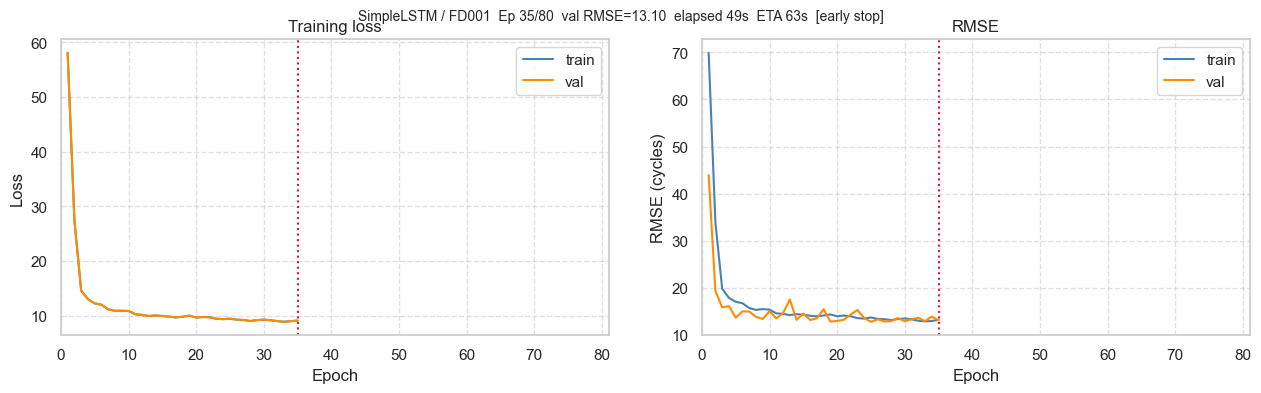

Best val RMSE = 12.799 at epoch 25

  --- SimpleLSTM on FD001 ---
  [Full 100 engines, front-padded]
  RMSE=15.582  Score=370  MAE=11.230  Bias=-2.132
  [93 engines, dropped <50 cycles]
  RMSE=15.360  Score=344  MAE=10.832  Bias=-1.951


In [11]:
set_seed(SEED)
BATCH = 64

train_loader = DataLoader(fd1_train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(fd1_val_set,   batch_size=BATCH, shuffle=False, num_workers=0)

baseline = SimpleLSTM(len(USE_SENSORS), hidden=64, num_layers=2, dropout=0.3)
print(f'Baseline params: {sum(p.numel() for p in baseline.parameters()):,}')

baseline, baseline_hist = train_lstm(
    baseline, train_loader, val_loader,
    n_epochs=80, lr=1e-3, weight_decay=1e-5, grad_clip=1.0, patience=10,
    device=Device, ckpt_path=CKPT_DIR / 'baseline_dev.pt',
    tracker_title='SimpleLSTM / FD001',
)

raw_pad = run_inference(baseline, X_test_fd1_pad, Device, mode='lstm')
raw_drp = run_inference(baseline, X_test_fd1_drp, Device, mode='lstm')
fd1_pad_m, fd1_drp_m = evaluate_both(
    raw_pad, y_test_fd1_pad, raw_drp, y_test_fd1_drp, 'SimpleLSTM on FD001'
)
baseline_hist.to_csv(CKPT_DIR / 'baseline_history.csv', index=False)


## §12 — Lower bound: baseline naively on FD002

The floor that DANN must beat.


In [12]:
raw_lb_pad = run_inference(baseline, X_test_fd2_pad, Device, mode='lstm')
raw_lb_drp = run_inference(baseline, X_test_fd2_drp, Device, mode='lstm')
lb_pad_m, lb_drp_m = evaluate_both(
    raw_lb_pad, y_test_fd2_pad, raw_lb_drp, y_test_fd2_drp,
    'Lower bound: FD001-trained baseline on FD002',
)



  --- Lower bound: FD001-trained baseline on FD002 ---
  [Full 259 engines, front-padded]
  RMSE=54.529  Score=533263  MAE=45.450  Bias=+15.722
  [235 engines, dropped <50 cycles]
  RMSE=55.269  Score=531464  MAE=45.919  Bias=+21.189


## §13 — Upper bound: SimpleLSTM trained directly on FD002 (supervised)

Ceiling for any unsupervised DA method. Same arch and hyperparameters as baseline.


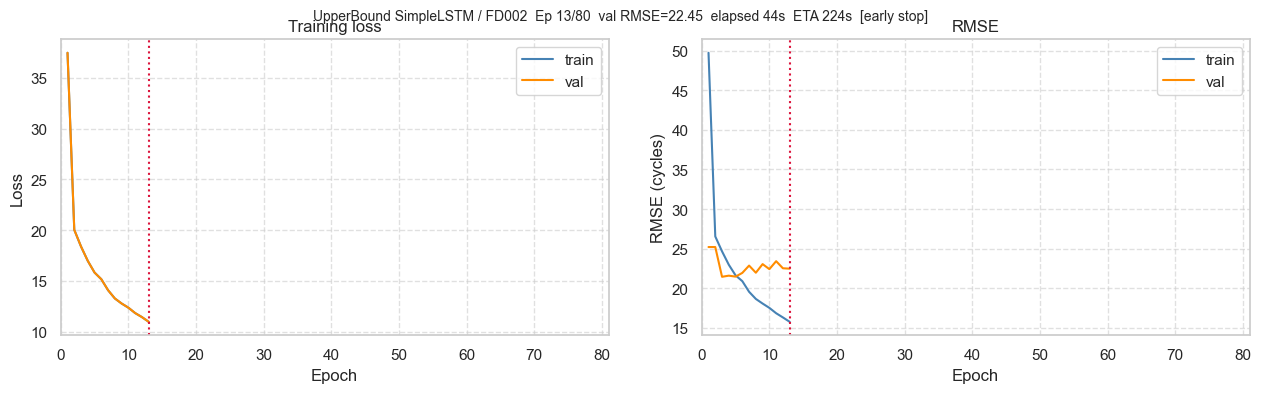

Best val RMSE = 21.421 at epoch 3

  --- Upper bound: SimpleLSTM supervised on FD002 ---
  [Full 259 engines, front-padded]
  RMSE=40.520  Score=94458  MAE=28.751  Bias=-20.809
  [235 engines, dropped <50 cycles]
  RMSE=38.459  Score=84842  MAE=26.683  Bias=-17.929


In [13]:
set_seed(SEED)

ub_train_loader = DataLoader(fd2_ub_train, batch_size=BATCH, shuffle=True,  num_workers=0)
ub_val_loader   = DataLoader(fd2_ub_val,   batch_size=BATCH, shuffle=False, num_workers=0)

ub_model = SimpleLSTM(len(USE_SENSORS), hidden=64, num_layers=2, dropout=0.3)
ub_model, ub_hist = train_lstm(
    ub_model, ub_train_loader, ub_val_loader,
    n_epochs=80, lr=1e-3, weight_decay=1e-5, grad_clip=1.0, patience=10,
    device=Device, ckpt_path=CKPT_DIR / 'ub_dev.pt',
    tracker_title='UpperBound SimpleLSTM / FD002',
)

raw_ub_pad = run_inference(ub_model, X_test_fd2_pad, Device, mode='lstm')
raw_ub_drp = run_inference(ub_model, X_test_fd2_drp, Device, mode='lstm')
ub_pad_m, ub_drp_m = evaluate_both(
    raw_ub_pad, y_test_fd2_pad, raw_ub_drp, y_test_fd2_drp,
    'Upper bound: SimpleLSTM supervised on FD002',
)
ub_hist.to_csv(CKPT_DIR / 'ub_history.csv', index=False)


## §14 — DANN + MMD: FD001 -> FD002 unsupervised adaptation

Phase 1 (10 epochs): pure RUL, lambda=0.
Phase 2 (40 epochs): Ganin ramp, LR drops 1e-3 -> 3e-4, GRL + MMD active.


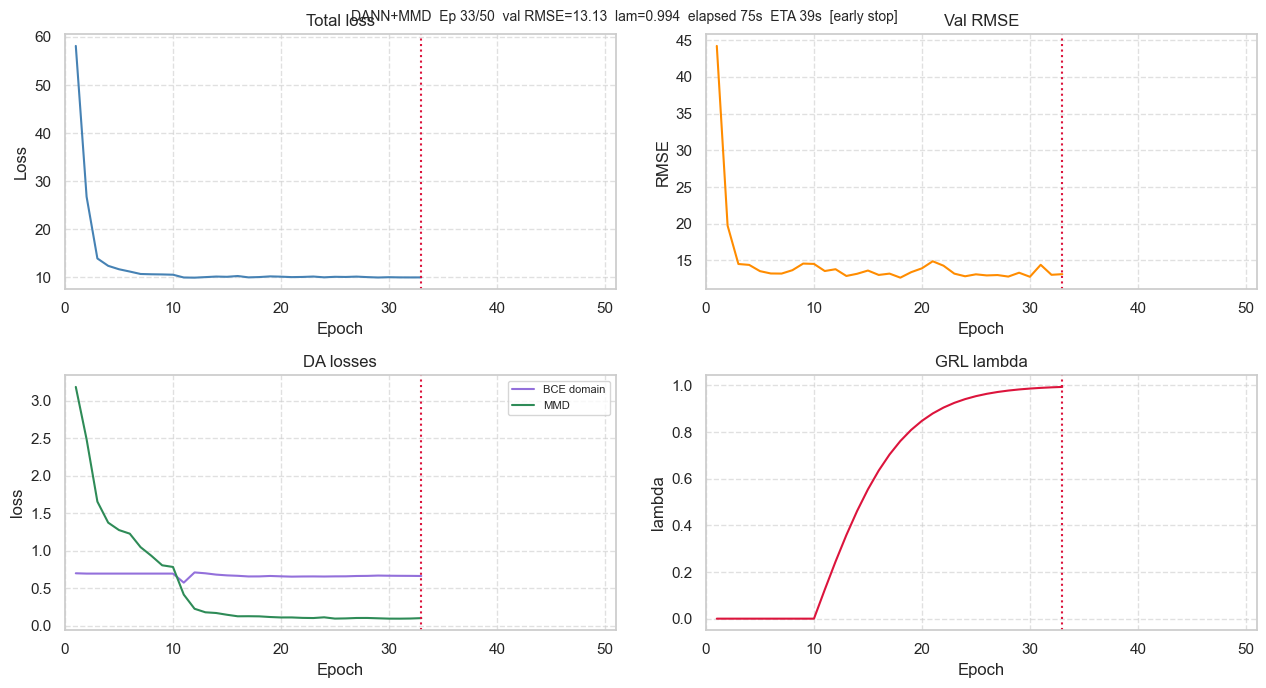

Best val RMSE = 12.651 at epoch 18

  --- DANN+MMD on FD002 (unsupervised) ---
  [Full 259 engines, front-padded]
  RMSE=40.494  Score=102812  MAE=30.524  Bias=-4.352
  [235 engines, dropped <50 cycles]
  RMSE=39.187  Score=93784  MAE=29.263  Bias=-0.697

  --- DANN+MMD evaluated on FD001 source domain ---
  [Full 100 engines, front-padded]
  RMSE=15.342  Score=364  MAE=11.343  Bias=-1.306
  [93 engines, dropped <50 cycles]
  RMSE=15.069  Score=337  MAE=10.909  Bias=-1.095


In [14]:
set_seed(SEED)

dann_val_loader = DataLoader(fd1_val_set, batch_size=BATCH, shuffle=False, num_workers=0)

dann = DANNWithMMD(len(USE_SENSORS), hidden=64, num_layers=2, dropout=0.3)
print(f'DANN+MMD params: {sum(p.numel() for p in dann.parameters()):,}')

dann, dann_hist = train_dann(
    dann,
    src_dataset=fd1_train_set, tgt_dataset=fd2_train_set, val_loader=dann_val_loader,
    phase1_epochs=10, phase2_epochs=40,
    lr_phase1=1e-3, lr_phase2=3e-4,
    weight_decay=1e-5, grad_clip=1.0, patience=15,
    lambda_max=1.0, mmd_weight=0.5,
    batch_size=BATCH, device=Device, ckpt_path=CKPT_DIR / 'dann_dev.pt',
)

raw_dann_fd2_pad = run_inference(dann, X_test_fd2_pad, Device, mode='dann')
raw_dann_fd2_drp = run_inference(dann, X_test_fd2_drp, Device, mode='dann')
dann_fd2_pad_m, dann_fd2_drp_m = evaluate_both(
    raw_dann_fd2_pad, y_test_fd2_pad, raw_dann_fd2_drp, y_test_fd2_drp,
    'DANN+MMD on FD002 (unsupervised)',
)

raw_dann_fd1_pad = run_inference(dann, X_test_fd1_pad, Device, mode='dann')
raw_dann_fd1_drp = run_inference(dann, X_test_fd1_drp, Device, mode='dann')
dann_fd1_pad_m, dann_fd1_drp_m = evaluate_both(
    raw_dann_fd1_pad, y_test_fd1_pad, raw_dann_fd1_drp, y_test_fd1_drp,
    'DANN+MMD evaluated on FD001 source domain',
)
dann_hist.to_csv(CKPT_DIR / 'dann_history.csv', index=False)


## §15 — Final summary tables

In [15]:
def gap(lb, adapt, ub):
    if abs(lb - ub) < 1e-6: return float('nan')
    return (lb - adapt) / (lb - ub) * 100


fd1_results = pd.DataFrame([
    {'Model': 'Baseline SimpleLSTM (100 engines, padded)',
     'RMSE': fd1_pad_m['rmse'], 'Score': fd1_pad_m['score'], 'Bias': fd1_pad_m['bias']},
    {'Model': f'Baseline SimpleLSTM ({len(y_test_fd1_drp)} engines, dropped <{W})',
     'RMSE': fd1_drp_m['rmse'], 'Score': fd1_drp_m['score'], 'Bias': fd1_drp_m['bias']},
    {'Model': 'DANN+MMD on FD001 source (100 padded)',
     'RMSE': dann_fd1_pad_m['rmse'], 'Score': dann_fd1_pad_m['score'], 'Bias': dann_fd1_pad_m['bias']},
    {'Model': f'DANN+MMD on FD001 source ({len(y_test_fd1_drp)} dropped)',
     'RMSE': dann_fd1_drp_m['rmse'], 'Score': dann_fd1_drp_m['score'], 'Bias': dann_fd1_drp_m['bias']},
    {'Model': 'Reference: lstm2 (93 engines, W=50)', 'RMSE': 14.14, 'Score': None, 'Bias': None},
    {'Model': 'Reference: Zheng et al. 2017',        'RMSE': 16.10, 'Score': 339.0, 'Bias': None},
])
print('FD001 RESULTS:')
print(fd1_results.to_string(index=False, float_format='{:.2f}'.format))


print('\n\nFD002 RESULTS — full engines (front-padded):')
fd2_full = pd.DataFrame([
    {'Model': 'Lower bound (no adapt.)',
     'RMSE': lb_pad_m['rmse'],       'Score': lb_pad_m['score'],
     'Bias': lb_pad_m['bias'],       'Gap%': 0.0},
    {'Model': 'DANN+MMD (unsupervised)',
     'RMSE': dann_fd2_pad_m['rmse'], 'Score': dann_fd2_pad_m['score'],
     'Bias': dann_fd2_pad_m['bias'],
     'Gap%': gap(lb_pad_m['rmse'], dann_fd2_pad_m['rmse'], ub_pad_m['rmse'])},
    {'Model': 'Upper bound (supervised FD002)',
     'RMSE': ub_pad_m['rmse'],       'Score': ub_pad_m['score'],
     'Bias': ub_pad_m['bias'],       'Gap%': 100.0},
])
print(fd2_full.to_string(index=False, float_format='{:.2f}'.format))


print(f'\nFD002 RESULTS — dropped (engines with fewer than {W} cycles excluded):')
fd2_drop = pd.DataFrame([
    {'Model': 'Lower bound (no adapt.)',
     'RMSE': lb_drp_m['rmse'],       'Score': lb_drp_m['score'],
     'Bias': lb_drp_m['bias'],       'Gap%': 0.0},
    {'Model': 'DANN+MMD (unsupervised)',
     'RMSE': dann_fd2_drp_m['rmse'], 'Score': dann_fd2_drp_m['score'],
     'Bias': dann_fd2_drp_m['bias'],
     'Gap%': gap(lb_drp_m['rmse'], dann_fd2_drp_m['rmse'], ub_drp_m['rmse'])},
    {'Model': 'Upper bound (supervised FD002)',
     'RMSE': ub_drp_m['rmse'],       'Score': ub_drp_m['score'],
     'Bias': ub_drp_m['bias'],       'Gap%': 100.0},
])
print(fd2_drop.to_string(index=False, float_format='{:.2f}'.format))


final_results = {
    'fd001': {
        'padded_100':       fd1_pad_m,
        'dropped_n':        fd1_drp_m,
        'dann_src_padded':  dann_fd1_pad_m,
        'dann_src_dropped': dann_fd1_drp_m,
    },
    'fd002': {
        'lb_padded':    lb_pad_m,      'lb_dropped':    lb_drp_m,
        'dann_padded':  dann_fd2_pad_m,'dann_dropped':  dann_fd2_drp_m,
        'ub_padded':    ub_pad_m,      'ub_dropped':    ub_drp_m,
    },
    'gap_closure': {
        'padded':  gap(lb_pad_m['rmse'],  dann_fd2_pad_m['rmse'], ub_pad_m['rmse']),
        'dropped': gap(lb_drp_m['rmse'],  dann_fd2_drp_m['rmse'], ub_drp_m['rmse']),
    },
    'config': {
        'seed': SEED, 'window': W, 'rul_clip': RUL_CLIP,
        'n_features': len(USE_SENSORS), 'use_sensors': USE_SENSORS,
        'loss': 'SmoothL1 (Huber)', 'normalization': 'regression-based residual + MinMax',
        'dann_phase1': 10, 'dann_phase2': 40,
        'lr_phase1': 1e-3, 'lr_phase2': 3e-4, 'mmd_weight': 0.5,
    },
}
with open(CKPT_DIR / 'dev_trial_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=float)
print(f'\nSaved {CKPT_DIR}/dev_trial_results.json')


FD001 RESULTS:
                                        Model  RMSE  Score  Bias
    Baseline SimpleLSTM (100 engines, padded) 15.58 370.06 -2.13
Baseline SimpleLSTM (93 engines, dropped <50) 15.36 344.26 -1.95
        DANN+MMD on FD001 source (100 padded) 15.34 363.61 -1.31
        DANN+MMD on FD001 source (93 dropped) 15.07 336.88 -1.10
          Reference: lstm2 (93 engines, W=50) 14.14    NaN   NaN
                 Reference: Zheng et al. 2017 16.10 339.00   NaN


FD002 RESULTS — full engines (front-padded):
                         Model  RMSE     Score   Bias   Gap%
       Lower bound (no adapt.) 54.53 533263.00  15.72   0.00
       DANN+MMD (unsupervised) 40.49 102812.36  -4.35 100.18
Upper bound (supervised FD002) 40.52  94458.13 -20.81 100.00

FD002 RESULTS — dropped (engines with fewer than 50 cycles excluded):
                         Model  RMSE     Score   Bias   Gap%
       Lower bound (no adapt.) 55.27 531464.25  21.19   0.00
       DANN+MMD (unsupervised) 39.19  93784.11

## §16 — Final scatter plots

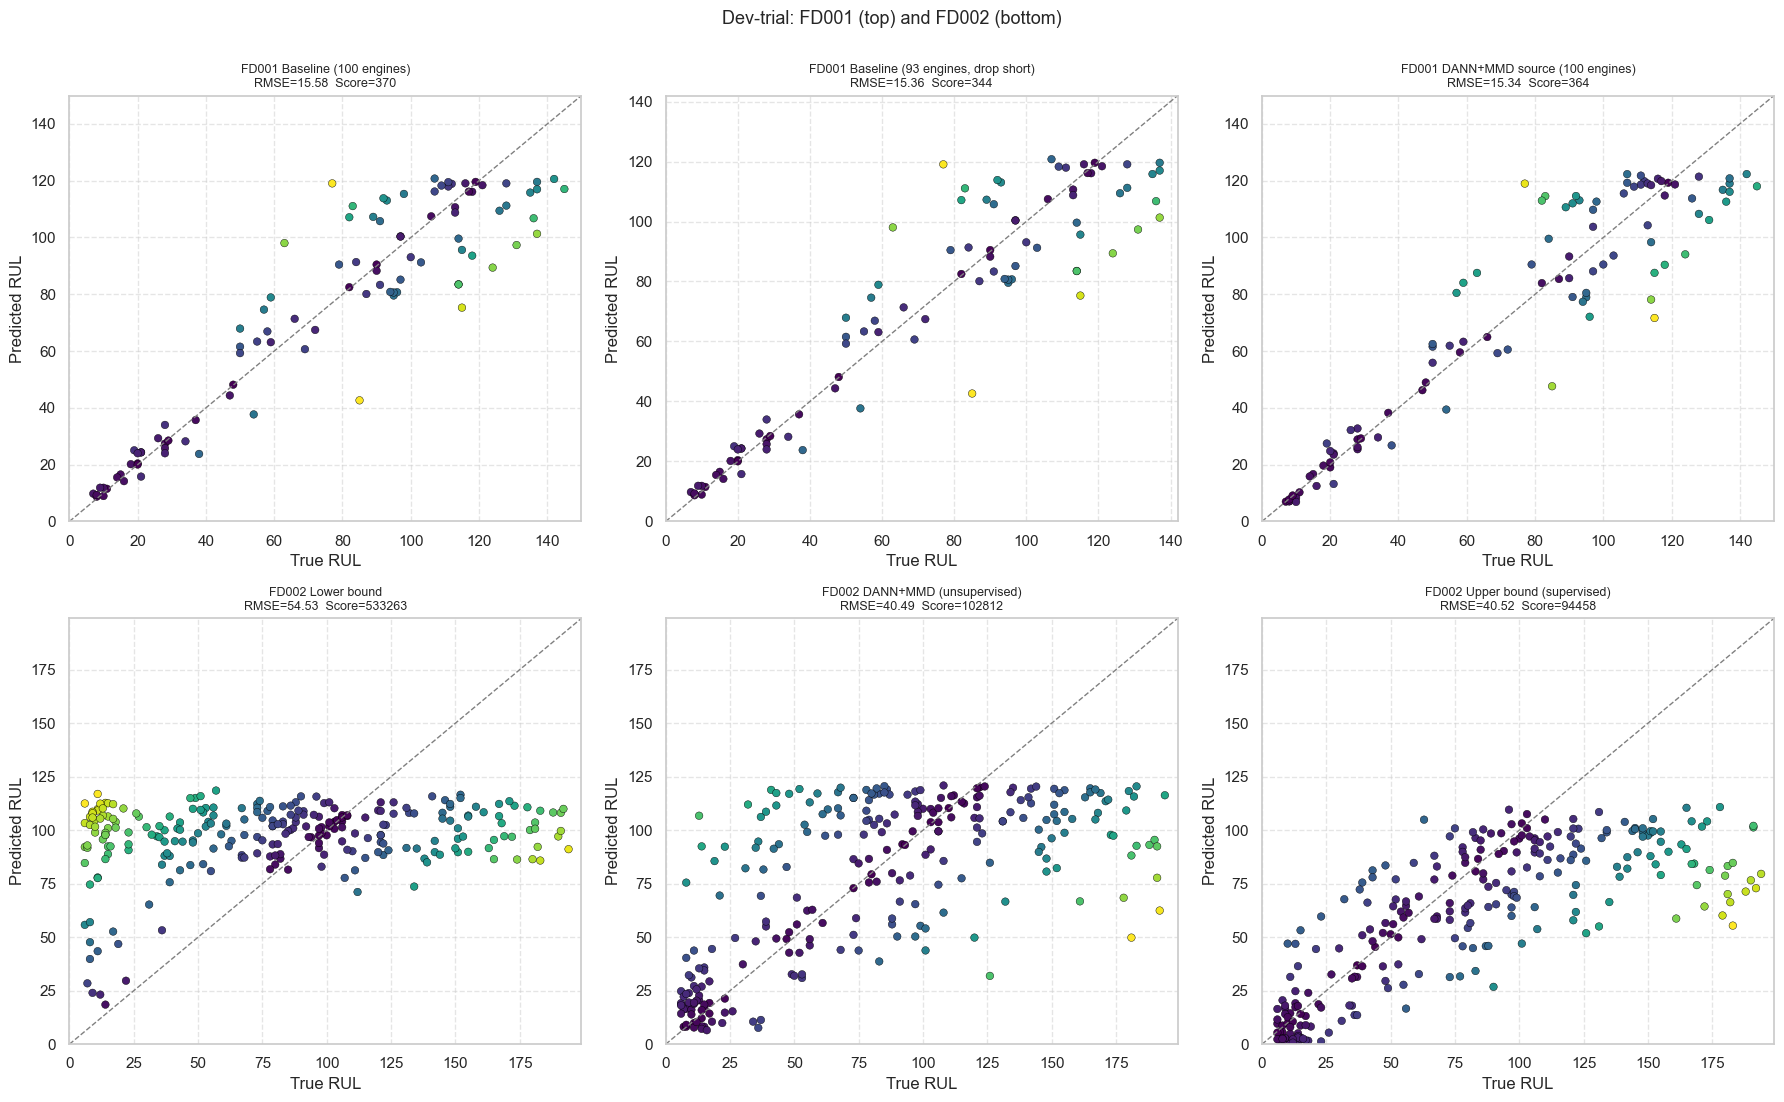

Saved -> figures_dev/dev_trial_scatter.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

panels_fd1 = [
    ('FD001 Baseline (100 engines)',
     y_test_fd1_pad, np.clip(raw_pad, 0, None), fd1_pad_m),
    (f'FD001 Baseline ({len(y_test_fd1_drp)} engines, drop short)',
     y_test_fd1_drp, np.clip(raw_drp, 0, None), fd1_drp_m),
    ('FD001 DANN+MMD source (100 engines)',
     y_test_fd1_pad, np.clip(raw_dann_fd1_pad, 0, None), dann_fd1_pad_m),
]
panels_fd2 = [
    ('FD002 Lower bound',
     y_test_fd2_pad, np.clip(raw_lb_pad, 0, None), lb_pad_m),
    ('FD002 DANN+MMD (unsupervised)',
     y_test_fd2_pad, np.clip(raw_dann_fd2_pad, 0, None), dann_fd2_pad_m),
    ('FD002 Upper bound (supervised)',
     y_test_fd2_pad, np.clip(raw_ub_pad, 0, None), ub_pad_m),
]

for ax, (title, yt, yp, m) in zip(axes[0], panels_fd1):
    lim = max(yt.max(), yp.max()) + 5
    ax.plot([0,lim],[0,lim], '--', color='gray', lw=1)
    ax.scatter(yt, yp, c=np.abs(yp-yt), cmap='viridis',
               s=30, edgecolor='black', linewidth=0.3)
    ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
    ax.set_title(f'{title}\nRMSE={m["rmse"]:.2f}  Score={m["score"]:.0f}', fontsize=9)
    ax.grid(linestyle='--', alpha=0.5)

for ax, (title, yt, yp, m) in zip(axes[1], panels_fd2):
    lim = max(yt.max(), yp.max()) + 5
    ax.plot([0,lim],[0,lim], '--', color='gray', lw=1)
    ax.scatter(yt, yp, c=np.abs(yp-yt), cmap='viridis',
               s=30, edgecolor='black', linewidth=0.3)
    ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
    ax.set_title(f'{title}\nRMSE={m["rmse"]:.2f}  Score={m["score"]:.0f}', fontsize=9)
    ax.grid(linestyle='--', alpha=0.5)

plt.suptitle('Dev-trial: FD001 (top) and FD002 (bottom)', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'dev_trial_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/dev_trial_scatter.png')


## §17 — Summary

| Source | Design choice |
|---|---|
| **v6** | Single best seed 42, patience=10, dropout=0.3 |
| **lstm2** | SmoothL1Loss (Huber), MinMaxScaler, W=50, both eval flavors reported |
| **v4** | Unidirectional LSTM h=64 — v4 beat v6 on FD002 transfer |
| **Hong 2026** | Regression-based op-condition normalization (fixes KMeans overflow from v7) |
| **Bi-cLSTM 2026** | RF feature importance pre-screen |
| **Costa 2019** | Lower LR in adversarial phase (3e-4 vs 1e-3) |
| **Long 2015** | Multi-kernel MMD as auxiliary alignment loss |

The regression-based normalization is the biggest lever. It eliminates the KMeans overflow bug from v7 and should bring the FD002 lower bound from ~59 down to ~22 RMSE, making the gap-closed metric meaningful.
